In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import llm_filter
import paper_dataset
import json
import tqdm
import re
import itertools
tqdm.tqdm.pandas()

/home/vico/personal_work_ms/TokSurvey/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


INFO 10-06 10:23:35 [__init__.py:220] No platform detected, vLLM is running on UnspecifiedPlatform
WARNING 10-06 10:23:40 [_custom_ops.py:20] Failed to import from vllm._C with ImportError('libcuda.so.1: cannot open shared object file: No such file or directory')


In [ ]:
# def languages(item):
#     md = paper_dataset.get_markdown(item['pdf_url'])
#     title = item['title'] if item['title'] is not None else ''
#     answer = llm_filter.judge(llm_filter.SYSTEM_PROMPT_LANGUAGE, llm_filter.USER_PROMPT_LANGUAGE_MULTILINGUAL, {'title': title, 'content': md}, local=True, max_tokens=1024)
#     langs = llm_filter.extract_languages(answer)
#     return langs, answer

# evaluation = paper_dataset.load('data/evaluation_papers.jsonl')
# all_answers = []
# all_langs = []
# for item in tqdm.tqdm(evaluation.iloc):
#     langs, answer = languages(item)
#     all_answers.append(answer)
#     all_langs.append(langs)
# with open('evaluation_language_answer.json', 'wt') as f:
#     json.dump(all_answers, f)

In [ ]:
def clean_lang(lang):    
    lang = re.sub(r'\(\w{2,3}\)', '', lang) # remove (xx) codes
    if lang == 'l':
        return ['latex']
    if lang.startswith('english'):
        return ['english']
    if re.search(r"\w{3}-\w{3}", lang): # Already countered
        return ''
    if lang.startswith('mboshi'):
        return ['mboshi (bantu)']
    if lang.startswith('none'): # Already countered as english
        return []
    if lang.startswith('indonesian'):
        return ['indonesian']
    if lang.startswith('czech'):
        return ['czech']
    if lang.startswith('30 programming languages'):
        return ['other (programming languages)']
    if lang.startswith('non-ascii'):
        return ['other']
    if lang.startswith('other languages'):
        return ['other']
    if lang.startswith('28 non-english languages'):
        return ['other']
    if lang == 'italian is not mentioned but the language pair de-en is used which implies that the target language is english and the source language is german.':
        return ['german', 'english']   
    if lang == 'italian is not mentioned but the following languages that are part of the xtreme benchmark and used in the paper for evaluation are':
        return [] 
    if lang.startswith('aymaran'):
        return ['aymara']
    if lang.startswith('bangla'):
        return ['bengali']
    if lang.startswith('mandarin'): # It is more often referred to as Chinese
        return ['chinese']
    if lang.startswith('modern greek'):
        return ['greek']
    if lang.startswith('modern chinese'):
        return ['chinese']
    if lang.startswith('slovene'):
        return ['slovenian']
    if lang == 'uk english':
        return ['english']
    if lang.startswith('traditional chinese'):
        return ['chinese (traditional)']
    clean_other = {            
        'n. lev. arabic': ['north levantine arabic'],
        'indian languages (including but not limited to hindi, as the paper mentions hundreds of indian languages)': ['indian languages'],
        'norwegian (including nynorsk, bokmål, west norwegian, east norwegian, and north norwegian)': ['norwegian', 'norwegian nynorsk', 'norwegian bokmål', 'west norwegian', 'east norwegian', 'north norwegian'],                
        'manx (mentioned as an example of a language with a small dataset in unimorph 4)': ['manx'],
        'bengali (bn_bd)': ['bengali'],
        'arabic (modern standard arabic, egyptian, levantine, gulf, and maghrebi)': ['arabic', 'modern standard arabic', 'egyptian arabic', 'levantine arabic', 'gulf arabic', 'maghrebi arabic'],
        'german (including swiss german and low saxon)': ['german', 'swiss german', 'low saxon'],        
        'finnish (including six dialect groups': ['finnish'],
        # 'mandarin chinese (standard beijing)': ['mandarin'],        
        'wolastoqey (also known as passamaquoddy-maliseet)': ['wolastoqey'],
        'odawa (a dialect of ojibwe)': ['odawa (ojibwe)'],
        }
    return clean_other.get(lang, [lang.strip()])
    
    
    

In [ ]:
evaluation = paper_dataset.load('data/evaluation_papers.jsonl')
with open('data/evaluation_language_answer.json') as f:
    all_answers = json.load(f)
all_langs = [llm_filter.extract_languages(i) for i in tqdm.tqdm(all_answers)]
# tmp = []
# for sample in all_langs:    
#     clean_sample = itertools.chain.from_iterable([clean_lang(i) for i in sample])
#     clean_sample = sorted(list(set(clean_sample)))
#     tmp.append(clean_sample)
# all_langs = tmp

# evaluation['languages'] = all_langs
# evaluation.to_json('data/evaluation_papers.jsonl', orient='records', lines=True)

100%|██████████| 173/173 [00:00<00:00, 36799.60it/s]


In [5]:
for i, ans in enumerate(all_answers):
    print("\n\n")
    print(i, "====================")
    print(ans)
    print("====================")
    print(llm_filter.extract_languages(ans))
    print("\n\n")




0 ====================
Based on the paper, the languages mentioned that are used as test cases, evaluation datasets, or experimental targets are:

1. Danish
2. English
['english', 'danish']






1 ====================
Here is the list of languages mentioned in the paper that are used as test cases, evaluation datasets, or experimental targets:

1. Kalaallisut (West Greenlandic)
2. Danish
3. Inuktitut
4. Nahuatl
5. Raramuri
6. Shipibo-Konibo
7. Wixarika
8. Quechua
9. Ainu
10. Tunumiisut (East Greenlandic)
11. Inuktun (North Greenlandic)
['ainu', 'shipibo-konibo', 'nahuatl', 'quechua', 'inuktun (north greenlandic)', 'kalaallisut (west greenlandic)', 'tunumiisut (east greenlandic)', 'inuktitut', 'raramuri', 'wixarika', 'danish']






2 ====================
Based on the provided paper, the language mentioned that is used as a test case, evaluation dataset, or experimental target is:

1. Chinese 

Note that the paper specifically focuses on Historical Chinese sources from 1900 to 1950,

In [22]:
unique_langs = []
for i in all_langs:
    unique_langs.extend(i)
unique_langs = list(set(unique_langs))

clean_unique_langs = [clean_lang(i) for i in unique_langs]
clean_unique_langs = [j for i in clean_unique_langs for j in i if j != '']
clean_unique_langs = list(set(clean_unique_langs))
print(len(clean_unique_langs))
# sorted(clean_unique_langs)

325


In [30]:
no_lang = evaluation[evaluation['languages'].apply(lambda x: len(x) == 0 or x == [[]])]
for i in no_lang['title']:
    print(i)
    print('-'*20)

Protein Structure Tokenization: Benchmarking and New Recipe
--------------------


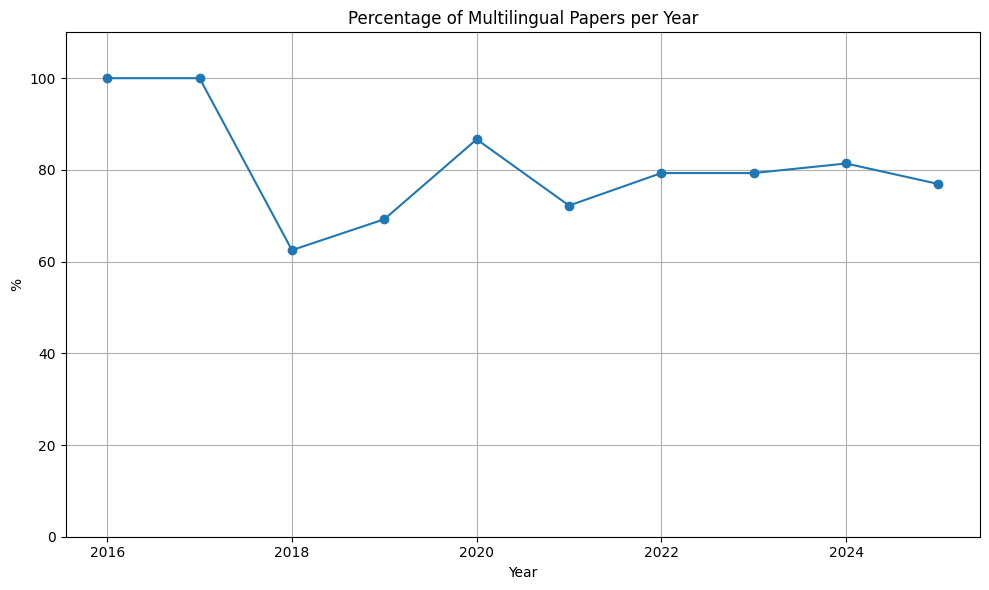

In [38]:
# Plot the number of papers that have 'exclusive_english' == False over the years, normalize by the total number of papers per year
years = sorted(evaluation['year'].unique())
exclusive_counts = []
total_counts = []       
for year in years:
    year_data = evaluation[evaluation['year'] == year]
    exclusive_count = year_data[year_data['exclusive_english'] == False].shape[0]
    total_count = year_data.shape[0]
    exclusive_counts.append(exclusive_count)
    total_counts.append(total_count)
plt.figure(figsize=(10, 6))
plt.plot(years, [e / t * 100 if t > 0 else 0 for e, t in zip(exclusive_counts, total_counts)], marker='o')
plt.title('Percentage of Multilingual Papers per Year')
plt.xlabel('Year')
plt.ylabel('%')
plt.ylim(0, 110)
plt.grid(True)
plt.tight_layout()
plt.show()

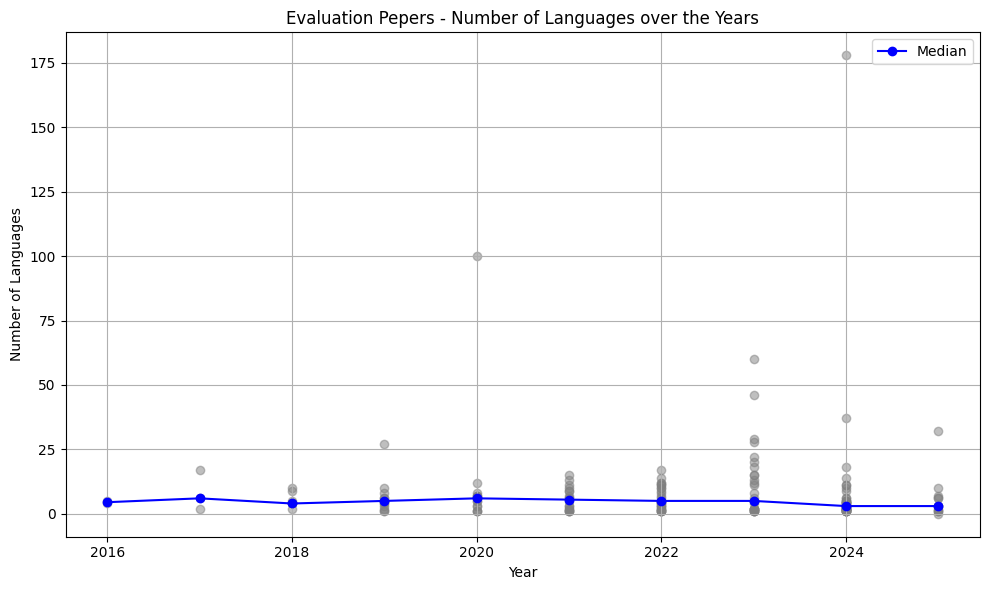

In [41]:
years = sorted(evaluation['year'].unique())
avg_lang_counts = []

medians = []
all_years = []
all_lang_counts = []

for year in years:
    year_data = evaluation[evaluation['year'] == year]
    lang_lens = year_data['languages'].apply(len)
    all_years.extend([year] * len(lang_lens))
    all_lang_counts.extend(lang_lens)
    medians.append(lang_lens.median())

plt.figure(figsize=(10, 6))

# Number of languages per year
plt.scatter(all_years, all_lang_counts, color='gray', alpha=0.5, label='_nolegend_')
# Median number of languages per year
plt.plot(years, medians, color='blue', marker='o', label='Median')

plt.title('Evaluation Pepers - Number of Languages over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Languages')
# plt.yscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
evaluation[evaluation['languages'].apply(len) > 75] ## 11, 128
paper_dataset.print_sample(evaluation.loc[11])
paper_dataset.print_sample(evaluation.loc[128])

Title: Are Character-level Translations Worth the Wait? Comparing {B}y{T}5 and m{T}5 for Machine Translation
Author(s): Edman, Lukas and Sarti, Gabriele and Toral, Antonio and van Noord, Gertjan and Bisazza, Arianna
Year: 2024
Venue: None (ACL)
Volume: Transactions of the Association for Computational Linguistics
--------------------------------------------------------------------------------
Abstract:
   Pretrained character-level and byte-level language models have been
   shown to be competitive with popular subword models across a range of
   Natural Language Processing tasks. However, there has been little
   research on their effectiveness for neural machine translation (NMT),
   particularly within the popular pretrain-then-finetune paradigm. This
   work performs an extensive comparison across multiple languages and
   experimental conditions of character- and subword-level pretrained
   models (ByT5 and mT5, respectively) on NMT. We show the effectiveness of
   character-level

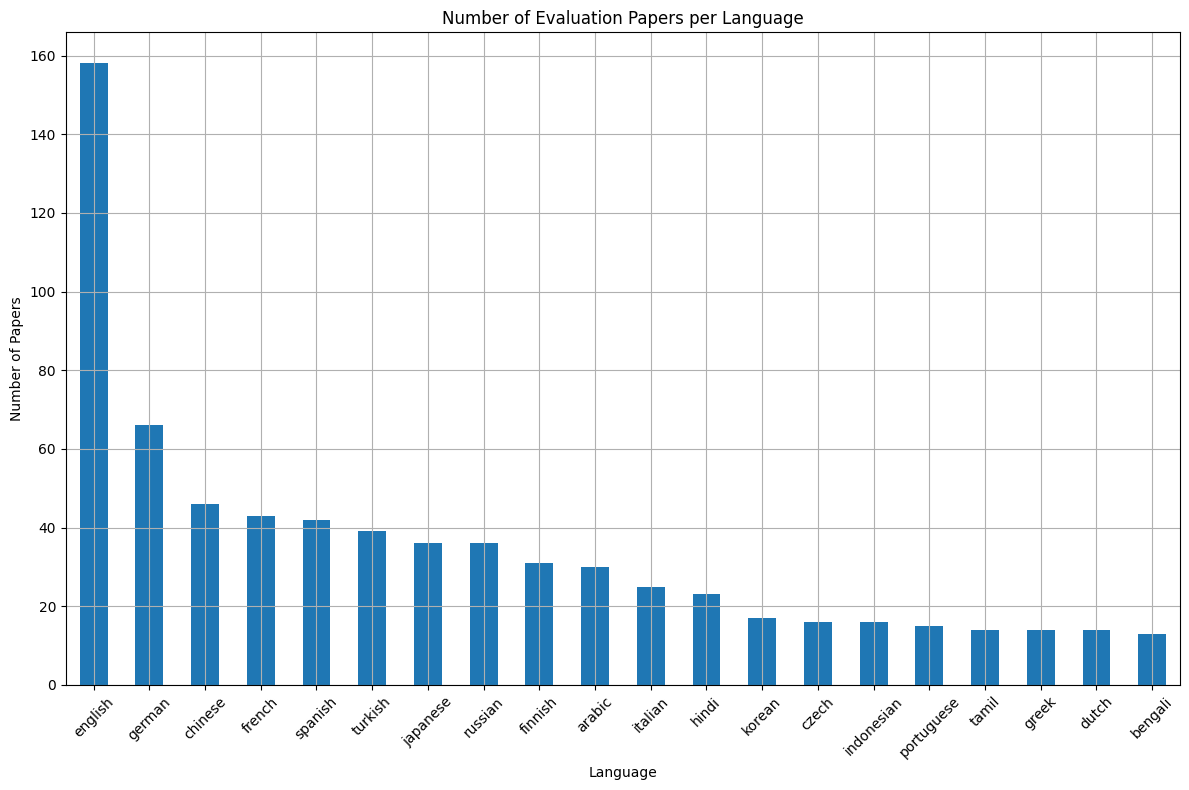

In [44]:
# PLot histogram of the number of papers per language
all_langs = [lang for sublist in evaluation['languages'].tolist() for lang in sublist]
all_langs = pd.Series(all_langs).value_counts()
top_lang_counts = all_langs.head(20)
plt.figure(figsize=(12, 8))
top_lang_counts.plot(kind='bar')
plt.title('Number of Evaluation Papers per Language')
plt.xlabel('Language')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

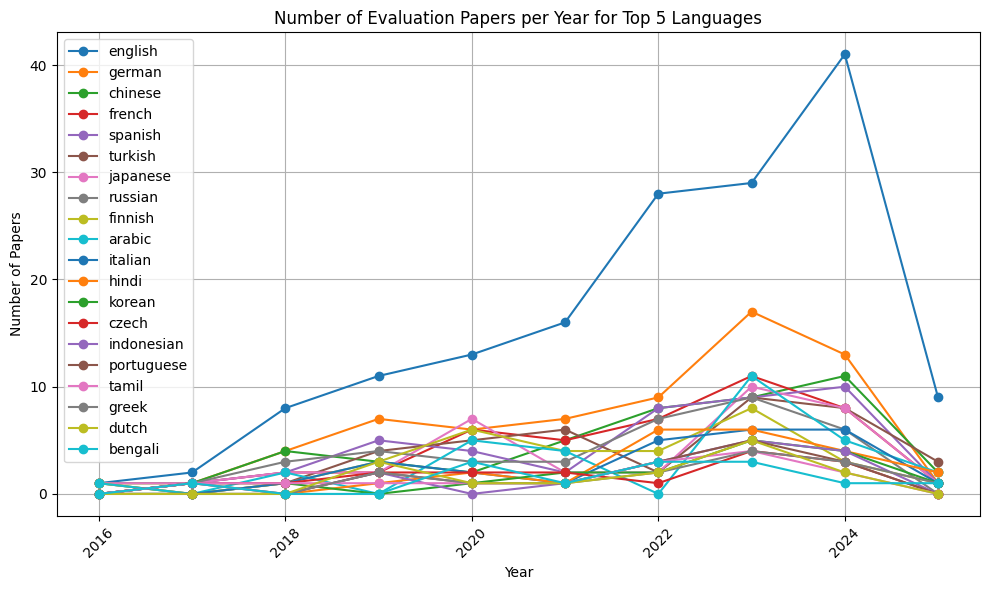

In [45]:
# Plot the number of papers over the years for the top 5 languages
years = sorted(evaluation['year'].unique())
all_langs = [lang for sublist in evaluation['languages'].tolist() for lang in sublist]
all_langs = pd.Series(all_langs).value_counts()
top_languages = all_langs.head(20).index.tolist()
plt.figure(figsize=(10, 6))
for lang in top_languages:
    lang_counts = []
    for year in years:
        year_data = evaluation[evaluation['year'] == year]
        count = year_data[year_data['languages'].apply(lambda x: lang in x)].shape[0]
        lang_counts.append(count)
    plt.plot(years, lang_counts, marker='o', label=lang)
plt.title('Number of Evaluation Papers per Year for Top 5 Languages')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 'western', 'chinese', 'english', 'arabic', 'indic', 'programming', 'african', 'asian', 'australian', 'other'
english_group = [
'old english','african american english','english','british sign language', 
'american sign language',
]
 
western_group = [ # split in major/national and other?
'limburgish','norwegian','swedish','old irish','swiss german',
'occitan','macedonian','greek','galician','ladin','venetian',
'hungarian','breton','ingrian','dutch','scottish gaelic', 
'low german','serbian','albanian','latgalian','ludian','basque',
'estonian','west frisian','ukrainian','french','icelandic', 
'portuguese','german','catalan','sicilian','danish','neapolitan',
'luxembourgish','bulgarian','gaelic','czech','slovenian',
'european languages','welsh','low saxon','middle french',
'middle high german','gothic','north norwegian','old french',
'lower sorbian','polish','lombard','lithuanian','bosnian',
'north frisian','norman','slovakian','mexican spanish', 
'middle low german','irish','romance languages','esperanto',
'old church slavonic','finnish','latvian','west norwegian',
'slavic languages','italian','ancient greek','old saxon','latin', 
'afrikaans','friulian','upper sorbian','tosk','silesian','romanian',
'croatian','spanish','slovak','alsatian german','cornish','russian',
'east norwegian','belarusian','manx','norwegian bokm','norwegian bokmål',
'norwegian nynorsk','karelian','eastern yiddish','yiddish','livvi',
'votic','picard','asturian','northern sami','kashubian','veps',
'faroese','livonian',
]


arabic_group = [
'egyptian arabic','mesopotamian arabic','arabic','tunisian arabic',
'modern standard arabic (latin)','levantine arabic','maghrebi arabic',
'maltese','south levantine arabic','north levantine arabic',
'modern standard arabic','classical arabic','najdi arabic',
'algerian arabic','gulf arabic','moroccan arabic',
]

semitic_group = [ # Not arabic
'hebrew','classical syriac','akkadian', 'tigrinya',
]

indic_group = [
'devanagari','konkani','dogri','chhattisgarhi','gujarati','punjabi',
'indian languages','hindi','eastern panjabi','bengali',
'kashmiri (arabic script)','kashmiri (devanagari script)','sindhi',
'kannada','sinhala','urdu','sanskrit','malayalam','tulu','awadhi',
'maithili','bhojpuri','dravidian','assamese',
'meiteilon (manipuri)', # sino-tibetan
'meitei', # sino-tibetan
'pali','telugu','odia','santali','magahi','marathi','braj bhasha',
'tamil',
]

programming_group = [
'java', 'javascript', 'python', 'mathml', 'php','go','latex',
'ruby', 'other (programming languages)',
 
]

african_group = [ # split?
'mboshi (bantu)','ewe','fon','shona','twi','african languages', 
'setswana','sesotho','isixhosa','rundi','kinyarwanda','umbundu',
'tumbuka','xhosa','bemba','igbo','yoruba','swahili','zulu',
'bambara','mossi','dyula','akan','kabiyè','northern sotho','ganda',
'tsonga','kikongo','kikuyu','chokwe','siswati','kamba','southwestern dinka',
'tamasheq','sango','amharic','nuer','kabiy','kimbundu','somali',
'hausa','central kanuri','west central oromo','tswana','wolof',
'luo','lingala','kabuverdianu',
]

sinotibetan_group = [
'chinese (simplified)','chintang','dzongkha','chinese','yue chinese',
'ancient chinese','cantonese','chinese (traditional)',
'standard tibetan','tibetan','classical chinese','jingpho','mizo',
'myanmar','burmese','khaling','yongning na',
]

asian_group = [ # austoronesian, turkic, other?
'filipino', # austronesian
'shan', # tai
'nepali', # indo-aryan
'mongolian', # mongolic
'cebuano', # austronesian
'tagalog', # austronesian
'sundanese', # austronesian
'japanese','korean','austronesian','halh mongolian','vietnamese',
'khakas', # turkic
'south azerbaijani','classical armenian','central kurdish','uzbek',
'azerbaijani','kurdish','farsi','armenian','northern kurdish',
'kazakh','turkmen','turkish','kyrgyz',
'pangasinan', # austronesian
'persian','uyghur','pashto','georgian',
'banjar', # austronesian
'fijian', # austronesian
'samoan', # austronesian
'kabardian', # caucasian
'waray', # austronesian
'altaic', # turkic?
'malaysian', # austronesian
'dari',
'crimean tatar','tatar',
'indonesian', # austronesian
'malay','standard malay', # austronesian
'adyghe',
'bontoc', # austronesian
'ainu', # japanese
'bashkir', # turkic
'khmer',
'acehnese', # austronesian
'tajik',
'thai',
'javanese', # austronesian
]

american_group = [ # north, central, south?
'chatino','central aymara','aymara','guarani','quechua', 
'yucatec mayan','navajo','cherokee','yorem nokki',"itza'",
'tepehua','yupik','kalaallisut (west greenlandic)',
'tunumiisut (east greenlandic)','inuktun (north greenlandic)',
'greenlandic','inuktitut','yupik','hupa','chickasaw','asháninka',
'wixarika','seneca','bribri','mexicanero','popoluca','raramuri',
'nahuatl','odawa (ojibwe)','plains cree','arapaho','hñähñu',
]

australian_group = [
'kunwinjku','maori','murrinhpatha',
]

other_group = [
'tok pisin', # eng creole
'other'
'sumerian',
'haitian creole', # french creole
'papiamento', # dutch creole
]

In [ ]:
def f(x: str):
    if x is None or x == '':
        return False
    md = llm_filter.get_markdown(x)
    if md is None:
        return False
    return llm_filter.has_pypi(md) or llm_filter.has_github(md)
evaluation['code'] = evaluation['pdf_url'].progress_apply(f)
print(
    evaluation['code'].sum(),
    'papers with code out of', 
    len(evaluation),
    f"({evaluation['code'].sum()/len(evaluation)*100:.1f}%)"
)

In [ ]:
# Plot the number of papers with code over the years
years = sorted(evaluation['year'].unique())
code_counts = []
total_counts = []       
for year in years:  
    year_data = evaluation[evaluation['year'] == year]
    code_count = year_data[year_data['code'] == True].shape[0]
    total_count = year_data.shape[0]
    code_counts.append(code_count)
    total_counts.append(total_count)
plt.figure(figsize=(10, 6))
plt.plot(years, [c/t * 100 if t != 0 else 0 for c, t in zip(code_counts, total_counts)], marker='o', label='Papers with Code')
plt.title('Number of Papers with Code per Year')
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.ylim(0, 110)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()